# Lab 11 — Multiple Access and Air Interfaces: Cells, 5G NR and Wi-Fi

**Companion to Chapters 20–22** (*Multiple Access and the Cellular Concept*; *Cellular
Generations: AMPS to 5G*; *Wi-Fi, Bluetooth and IoT*).
**Time needed:** about 90 minutes. **Difficulty:** core.

A physical layer moves bits over one link; an air interface shares a scarce spectrum among
thousands of users, in space (cells), in time and frequency (TDMA/OFDMA), and in politeness
(Wi-Fi's listen-before-talk). This lab walks up that stack: the cellular reuse trade-off and
Erlang's trunking law that shaped AMPS and GSM, then the 5G NR resource grid, schedulers and link
adaptation, and finally Wi-Fi's contention MAC and the EVM budget of 4096-QAM in Wi-Fi 7.

### What you will learn
1. Compute co-channel SIR versus frequency-reuse factor, and size a cell with Erlang B.
2. Lay out an NR slot's resource grid and count its overhead.
3. Compare round-robin, max-rate and proportional-fair OFDMA schedulers.
4. See why the uplink uses DFT-s-OFDM, and build link adaptation from the NR MCS table.
5. Simulate CSMA/CA contention and a 4096-QAM EVM budget.

### Prerequisites
Labs 5 and 7 (channels, OFDM). Chapters 20–22.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The cellular concept: reuse and co-channel SIR | |
| 2 | Trunking: Erlang B | |
| 3 | NR numerology and a slot's resource grid | |
| 4 | OFDMA scheduling and multi-user diversity | yes |
| 5 | Uplink PAPR: DFT-s-OFDM | yes |
| 6 | Link adaptation and HARQ | yes |
| 7 | Wi-Fi: CSMA/CA contention | |
| 8 | Wi-Fi 7's 4096-QAM: an EVM budget | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=11, lab="11")

Lab 11 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 11


## 1. The cellular concept: reuse and co-channel SIR

Bell Labs' insight (Chapter 20): reuse the same frequencies in cells far enough apart. With a
hexagonal layout and cluster size $N$ (1, 3, 4, 7, ...), co-channel cells are $D = R\sqrt{3N}$ apart,
and a user at the cell edge with six first-tier interferers and path-loss exponent $n$ sees

$$\mathrm{SIR} \approx \frac{(D/R)^n}{6} = \frac{(3N)^{n/2}}{6}.$$

AMPS needed about 18 dB and chose $N = 7$; GSM, with coding and frequency hopping, used 3–4; CDMA
and LTE/NR run $N = 1$ and fight interference with coding, scheduling and coordination instead.
Below, users are dropped uniformly in the centre cell and the downlink SIR is computed exactly
against the first tier of co-channel cells.

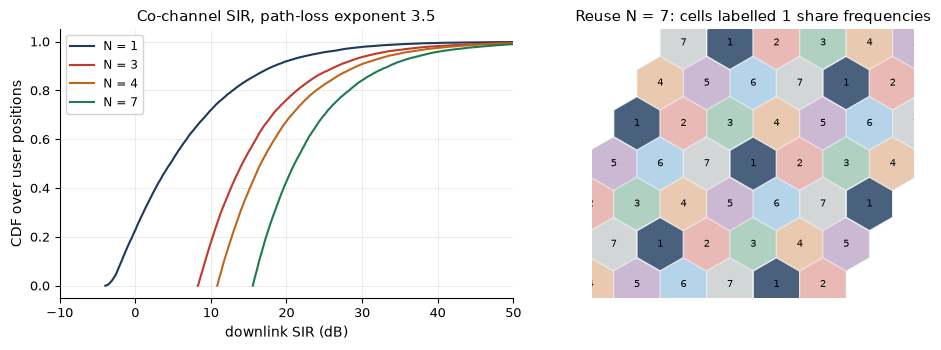

cluster size N,edge SIR formula (dB),5th percentile (dB),median (dB)
1,0.6,-2.5,4.6
3,8.9,8.8,14.2
4,11.1,11.3,16.6
7,15.4,16.0,21.1


In [3]:
def sir_samples(N, n_exp, users=20000, sigma_db=0.0):
    D = np.sqrt(3 * N)                                  # in units of the cell radius R
    ang = np.pi / 6 + np.arange(6) * np.pi / 3          # first-tier co-channel cell directions
    bs = D * np.exp(1j * ang)
    r = np.sqrt(rng.random(users)) * 0.95               # uniform in a disk ≈ hexagon
    u = r * np.exp(2j * np.pi * rng.random(users))
    sh = lambda shape: 10 ** (sigma_db * rng.standard_normal(shape) / 10)
    s = np.abs(u) ** -n_exp * sh(users)
    i = np.sum(np.abs(u[:, None] - bs[None, :]) ** -n_exp * sh((users, 6)), axis=1)
    return lk.db(s / i)

f, ax = lk.fig("row2", 1, 2)
rows = []
for N, col in [(1, lk.NAVY), (3, lk.RED), (4, lk.ORANGE), (7, lk.GREEN)]:
    v = np.sort(sir_samples(N, 3.5))
    ax[0].plot(v, np.arange(1, len(v) + 1) / len(v), color=col, label=f"N = {N}")
    rows.append([N, lk.db((3 * N) ** 1.75 / 6), np.percentile(v, 5), np.median(v)])
ax[0].set_xlabel("downlink SIR (dB)"); ax[0].set_ylabel("CDF over user positions"); ax[0].legend()
ax[0].set_title("Co-channel SIR, path-loss exponent 3.5"); ax[0].set_xlim(-10, 50)
# a picture of a 7-cell cluster
for q in range(-3, 4):
    for r_ in range(-3, 4):
        c = np.sqrt(3) * (q + r_ / 2) + 1j * 1.5 * r_
        cell_id = (q + 3 * r_) % 7
        hexa = c + np.exp(1j * (np.pi / 6 + np.arange(7) * np.pi / 3))
        ax[1].fill(hexa.real, hexa.imag, color=lk.PALETTE[cell_id], alpha=0.35 if cell_id else 0.8,
                   edgecolor="white")
        ax[1].text(c.real, c.imag, str(cell_id + 1), ha="center", va="center", fontsize=7, clip_on=True)
ax[1].set_aspect("equal"); ax[1].axis("off"); ax[1].set_title("Reuse N = 7: cells labelled 1 share frequencies")
ax[1].set_xlim(-6, 6); ax[1].set_ylim(-5, 5)
lk.show(f)
lk.table(rows, ["cluster size N", "edge SIR formula (dB)", "5th percentile (dB)", "median (dB)"], fmt=".1f")

**What you should see.** Larger clusters shift the SIR distribution right by roughly
$17.5\log_{10}(7/3) \approx 6.4$ dB from $N=3$ to $N=7$, at the cost of $N$ times fewer channels per cell.
The formula matches the worst (5th percentile) users, not the median ones.

### Try it yourself 1.1
With path-loss exponent $n = 4$, what edge SIR (dB) does the formula give for $N = 7$?

In [5]:
answer_1_1 = None
lk.check("1.1 SIR for N = 7, n = 4", answer_1_1, lk.db(21 ** 2 / 6), atol=0.1)

[TODO] 1.1 SIR for N = 7, n = 4: not attempted yet: replace the None with your answer

## 2. Trunking: Erlang B

Calls arrive at random and last a random time. With $C$ channels and offered traffic $A$ erlangs
(arrival rate × mean holding time), the probability that a new call is blocked is Erlang's B formula,
computed stably by the recursion $B(A,0) = 1$, $B(A,c) = \dfrac{A\,B(A,c-1)}{c + A\,B(A,c-1)}$.
The key insight: big trunks are more efficient. 10 channels carry about 5 erlangs at 2% blocking
(50% utilisation); 100 channels carry about 88 (88%).

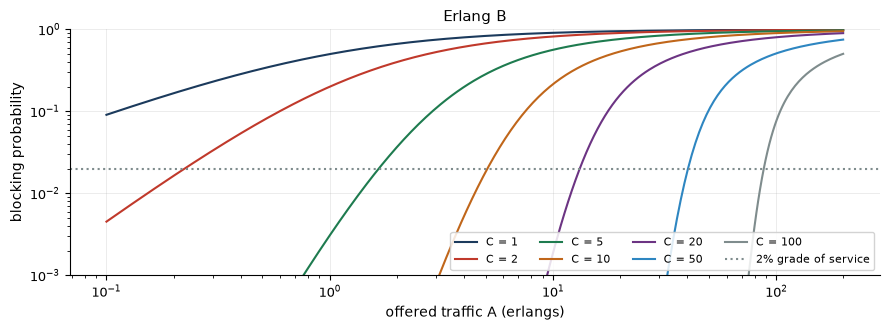

In [7]:
def erlang_b(A, C):
    B = np.ones_like(np.asarray(A, dtype=float))
    for c in range(1, C + 1):
        B = A * B / (c + A * B)
    return B

A = np.logspace(-1, 2.3, 400)
f, ax = lk.fig("wide")
for C in [1, 2, 5, 10, 20, 50, 100]:
    ax.loglog(A, erlang_b(A, C), label=f"C = {C}")
ax.axhline(0.02, color=lk.GRAY, ls=":", label="2% grade of service")
ax.set_ylim(1e-3, 1); ax.set_xlabel("offered traffic A (erlangs)"); ax.set_ylabel("blocking probability")
ax.legend(ncol=4, fontsize=8); ax.set_title("Erlang B")
lk.show(f)

### Try it yourself 2.1
A GSM cell with 3 carriers has about 22 traffic channels. Using `erlang_b` and a root finder, how many
erlangs can it carry at 2% blocking?

In [9]:
answer_2_1 = None
from scipy.optimize import brentq
lk.check("2.1 capacity of 22 channels at 2% blocking (erlangs)", answer_2_1,
         brentq(lambda a: erlang_b(a, 22) - 0.02, 1, 30), rtol=0.01)

[TODO] 2.1 capacity of 22 channels at 2% blocking (erlangs): not attempted yet: replace the None with your answer

## 3. NR numerology and a slot's resource grid

Subcarrier spacing $\Delta f = 15\cdot 2^{\mu}$ kHz; a slot is always 14 OFDM symbols (normal CP), so
slots shrink as $\mu$ grows (TS 38.211). One resource block (RB) is 12 subcarriers. Below, a simplified
downlink slot over 4 RBs: PDCCH (control) in the first two symbols, a front-loaded DM-RS in symbol 2
(type-A mapping), an additional DM-RS in symbol 11 for mobility, PT-RS-like tracking pilots and PDSCH data.

μ,SCS (kHz),slot (ms),symbol (µs),CP (µs),RB (kHz)
0,15,1.0000,66.67,4.688,180
1,30,0.5000,33.33,2.344,360
2,60,0.2500,16.67,1.172,720
3,120,0.1250,8.33,0.586,1440
4,240,0.0625,4.17,0.293,2880


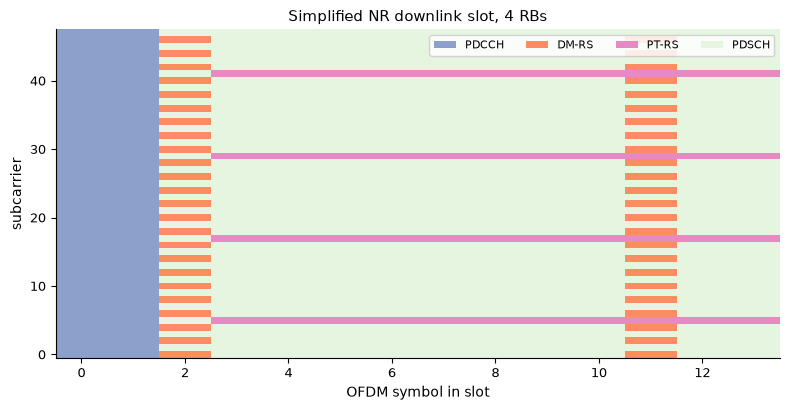

Reference-signal + control overhead: 28.0%


In [11]:
rows = []
for mu in range(0, 5):
    d = cl.nr_numerology(mu)
    rows.append([mu, d["scs_khz"], d["slot_ms"], d["useful_symbol_us"], d["cp_us"], d["rb_bandwidth_khz"]])
lk.table(rows, ["μ", "SCS (kHz)", "slot (ms)", "symbol (µs)", "CP (µs)", "RB (kHz)"],
         fmt={1: ".0f", 2: ".4f", 3: ".2f", 4: ".3f", 5: ".0f"})
nsc, nsym = 48, 14
grid = np.full((nsc, nsym), 3)                 # 3 = PDSCH
grid[:, :2] = 0                                # PDCCH region
for s_ in (2, 11):
    grid[::2, s_] = 1                          # DM-RS type 1: every other subcarrier
grid[5::12, 3:] = np.where(grid[5::12, 3:] == 3, 2, grid[5::12, 3:])
cmap = ListedColormap(["#8da0cb", "#fc8d62", "#e78ac3", "#e5f5e0"])
f, ax = lk.fig((8, 4.2))
ax.imshow(grid, aspect="auto", origin="lower", cmap=cmap, interpolation="nearest")
ax.set_xlabel("OFDM symbol in slot"); ax.set_ylabel("subcarrier")
for lab, col in zip(["PDCCH", "DM-RS", "PT-RS", "PDSCH"], cmap.colors):
    ax.bar(0, 0, color=col, label=lab)
ax.legend(loc="upper right", fontsize=8, ncol=4); ax.set_title("Simplified NR downlink slot, 4 RBs")
ax.grid(False)
lk.show(f)
print(f"Reference-signal + control overhead: {np.mean(grid != 3):.1%}")

## 4. OFDMA scheduling and multi-user diversity

Each user sees an independent frequency-selective channel (EVA profile at 30 kHz SCS). Per resource
block and slot, the scheduler picks one user:

* **Round robin (RR)** ignores the channel.
* **Max-rate** picks the best instantaneous rate: maximum cell throughput, starved cell edge.
* **Proportional fair (PF)** picks $\arg\max_u r_u/\bar R_u^{\alpha}$, with $\bar R_u$ an exponentially
  averaged throughput; $\alpha = 1$ is classic PF.

Rates use the Shannon formula with a 3 dB implementation gap. Jain's fairness index is
$(\sum x_u)^2/(U\sum x_u^2)$: 1 is perfectly fair.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

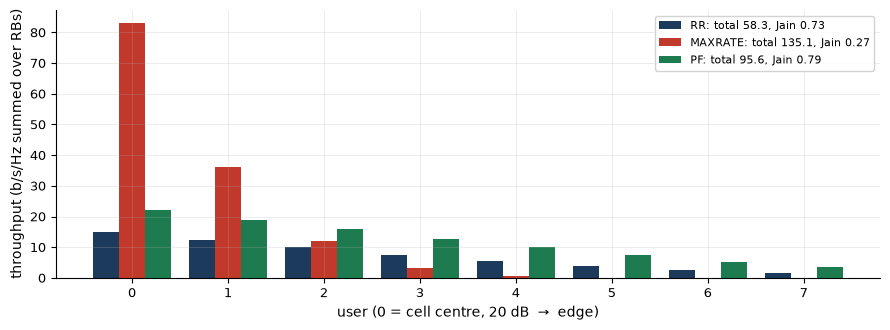

In [13]:
def user_channels(n_users, n_rb, n_slots, mean_snr_db, rng):
    """(slots, users, RBs) SNR from block-fading frequency-selective channels."""
    delays, pdb = cl.TDL_PROFILES["EVA"]
    p = 10 ** (np.array(pdb) / 10); p /= p.sum()
    f_rb = np.arange(n_rb) * 12 * 30e3
    E = np.exp(-2j * np.pi * np.outer(np.array(delays) * 1e-9, f_rb))
    g = (rng.standard_normal((n_slots, n_users, len(p))) + 1j * rng.standard_normal((n_slots, n_users, len(p)))) * np.sqrt(p / 2)
    return lk.undb(np.array(mean_snr_db))[None, :, None] * np.abs(g @ E) ** 2

def schedule(snr, policy="pf", alpha=1.0, tc=50):
    S, U, R = snr.shape
    rate = np.log2(1 + snr / 10 ** 0.3)
    avg = np.full(U, 1e-3); served = np.zeros(U)
    for s_ in range(S):
        if policy == "rr":
            pick = (s_ * R + np.arange(R)) % U
        elif policy == "maxrate":
            pick = np.argmax(rate[s_], axis=0)
        else:
            pick = np.argmax(rate[s_] / avg[:, None] ** alpha, axis=0)
        inst = np.bincount(pick, weights=rate[s_, pick, np.arange(R)], minlength=U)
        avg = (1 - 1 / tc) * avg + inst / tc
        served += inst
    return served / S

def sched_demo(n_users=8, edge_snr_db=0.0, alpha=1.0):
    mean = np.linspace(20, edge_snr_db, n_users)
    snr = user_channels(n_users, 24, 300, mean, rng)
    f, ax = lk.fig("wide")
    w = 0.27
    for i, (pol, a) in enumerate([("rr", 1), ("maxrate", 1), ("pf", alpha)]):
        thr = schedule(snr, pol, a)
        ax.bar(np.arange(n_users) + (i - 1) * w, thr, w,
               label=f"{pol.upper()}: total {thr.sum():.1f}, Jain {thr.sum() ** 2 / (n_users * np.sum(thr ** 2)):.2f}")
    ax.set_xlabel("user (0 = cell centre, 20 dB  →  edge)"); ax.set_ylabel("throughput (b/s/Hz summed over RBs)")
    ax.legend(fontsize=8)
    lk.show(f)

lk.interact(sched_demo, n_users=lk.islider(8, 2, 16, 1, "users"),
            edge_snr_db=lk.slider(0, -10, 20, 1, "edge SNR (dB)"), alpha=lk.slider(1.0, 0.0, 3.0, 0.1, "PF α"))

**What you should see.** Max-rate gives the highest total but almost nothing to the edge users;
round robin is fair in time but wastes good channels; PF gets close to max-rate's total while serving
everybody, because it schedules each user on *their own* peaks: multi-user diversity.

## 5. Uplink PAPR: why NR offers DFT-s-OFDM

A handset PA must back off by roughly the signal's PAPR to stay linear. DFT precoding makes the
transmitted signal single-carrier-like and cuts the PAPR by several dB for QPSK, which is uplink
coverage. LTE's uplink is DFT-s-OFDM only; NR (Rel-15) supports it for single-layer uplink
alongside CP-OFDM.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

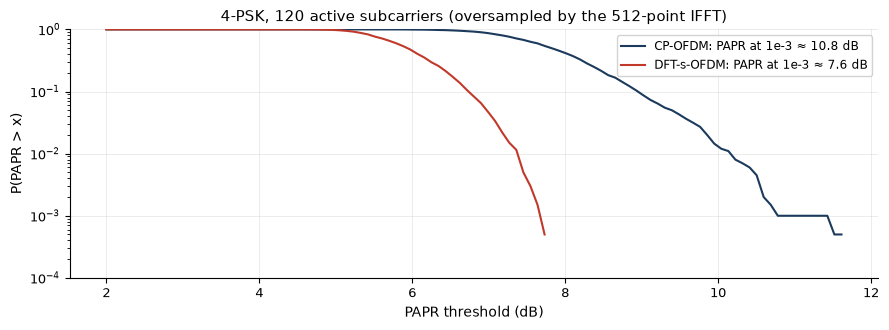

In [16]:
def papr_demo(mod="qpsk", n_used=120):
    cfg = cl.OFDMConfig(nfft=512, n_used=n_used, ncp=36)
    c = cl.get_constellation(mod)
    n_sym = 2000
    sym = c.modulate(cl.random_bits(c.k * n_used * n_sym, rng)).reshape(n_sym, n_used)
    f, ax = lk.fig("wide")
    for x, lab in [(cl.ofdm_modulate(sym, cfg), "CP-OFDM"), (cl.dft_s_ofdm_modulate(sym, cfg), "DFT-s-OFDM")]:
        g, cc = cl.ccdf(cl.papr_db(x, cfg.sym_len), np.linspace(2, 13, 120))
        ax.semilogy(g, np.where(cc > 0, cc, np.nan), label=f"{lab}: PAPR at 1e-3 ≈ {g[np.argmin(np.abs(cc - 1e-3))]:.1f} dB")
    ax.set_xlabel("PAPR threshold (dB)"); ax.set_ylabel("P(PAPR > x)"); ax.set_ylim(1e-4, 1)
    ax.legend(); ax.set_title(f"{c.name}, {n_used} active subcarriers (oversampled by the 512-point IFFT)")
    lk.show(f)

lk.interact(papr_demo, mod=lk.choice(["qpsk", "16qam", "64qam", "256qam"], "qpsk", "modulation"),
            n_used=lk.islider(120, 12, 240, 12, "subcarriers"))

**What you should see.** About 3–4 dB less PAPR for DFT-s-OFDM with QPSK; the advantage shrinks for
dense QAM, whose own constellation PAPR adds on top.

## 6. Link adaptation and HARQ

The gNB picks a modulation and coding scheme from CQI reports to hit about 10% initial BLER, and
HARQ retransmissions clean up the rest. Spectral efficiencies below are from TS 38.214 Table
5.1.3.1-1 (the 64-QAM table). The SNR each MCS needs is *modelled* as the Shannon SNR plus a gap,
a common abstraction in system-level simulators (a real curve needs link-level simulation, Lab 9).
HARQ chase combining is modelled as SNR adding over $k$ transmissions while the rate divides by $k$.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

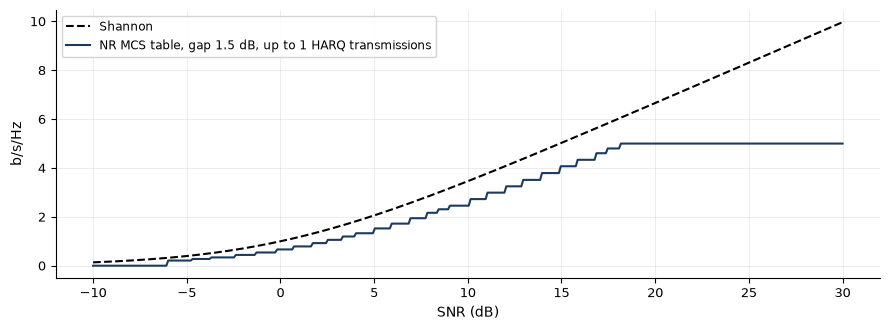

In [19]:
mcs = [(2, 120), (2, 157), (2, 193), (2, 251), (2, 308), (2, 379), (2, 449), (2, 526), (2, 602), (2, 679),
       (4, 340), (4, 378), (4, 434), (4, 490), (4, 553), (4, 616), (4, 658), (6, 438), (6, 466), (6, 517),
       (6, 567), (6, 616), (6, 666), (6, 719), (6, 772), (6, 822), (6, 873), (6, 910), (6, 948)]
se = np.array([q * r / 1024 for q, r in mcs])

def la_demo(gap_db=1.5, harq_tx=1):
    snr = np.linspace(-10, 30, 400)
    req = lk.db(2 ** se - 1) + gap_db
    tput = np.zeros_like(snr)
    for k in range(1, harq_tx + 1):
        idx = np.searchsorted(req, snr + lk.db(k), side="right") - 1
        tput = np.maximum(tput, np.where(idx >= 0, se[np.clip(idx, 0, None)] * 0.9 / k, 0))
    f, ax = lk.fig("wide")
    ax.plot(snr, np.log2(1 + lk.undb(snr)), "k--", label="Shannon")
    ax.plot(snr, tput, label=f"NR MCS table, gap {gap_db} dB, up to {harq_tx} HARQ transmissions")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("b/s/Hz"); ax.legend()
    lk.show(f)

lk.interact(la_demo, gap_db=lk.slider(1.5, 0, 6, 0.5, "gap (dB)"), harq_tx=lk.islider(1, 1, 4, 1, "max HARQ tx"))

**What you should see.** A staircase following Shannon a gap-width to the right, topping out at
about 5.0 b/s/Hz: the top MCS (64-QAM, rate 948/1024, 5.55 b/s/Hz) times 0.9 for the 10% initial
BLER target. HARQ extends coverage below the lowest MCS at a reduced rate.

## 7. Wi-Fi: CSMA/CA contention

Wi-Fi's distributed coordination function has no scheduler. A station with data waits for the
medium to be idle, then counts down a random backoff drawn from $[0, CW-1]$ slots; if two stations
reach zero in the same slot, they collide, and each doubles its contention window (up to $CW_{\max}$).
Below: a slot-level simulation of $n$ saturated stations (always have a packet), with a packet
lasting 50 slots and a collision wasting the same time. Throughput is the fraction of time carrying
successful packets (compare Bianchi, 2000).

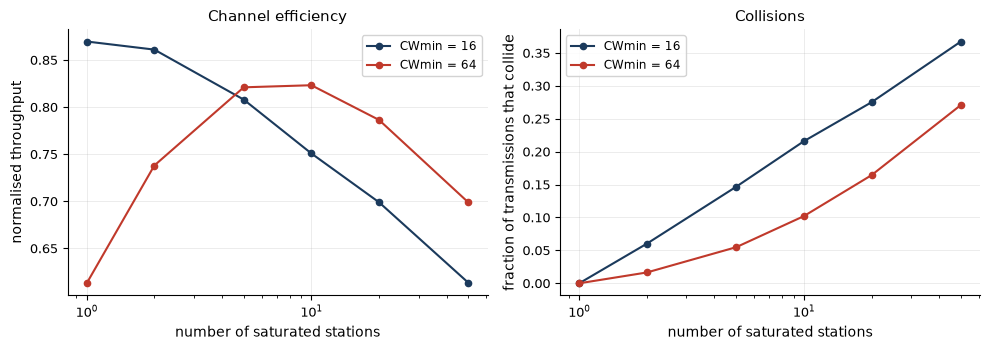

In [22]:
def dcf_sim(n, cw_min=16, cw_max=1024, pkt_slots=50, events=20000):
    cw = np.full(n, cw_min)
    bo = rng.integers(0, cw)
    busy = succ = colls = attempts = 0
    idle = 0
    for _ in range(events):
        m = bo.min()                       # idle slots until the next transmission attempt
        idle += m
        bo -= m
        tx = np.flatnonzero(bo == 0)
        attempts += len(tx)
        if len(tx) == 1:
            succ += 1
            cw[tx] = cw_min
        else:
            colls += 1
            cw[tx] = np.minimum(2 * cw[tx], cw_max)
        busy += pkt_slots
        bo[tx] = rng.integers(0, cw[tx])
    thr = succ * pkt_slots / (busy + idle)
    return thr, colls / events

ns = [1, 2, 5, 10, 20, 50]
rows = []
f, ax = lk.fig("row2", 1, 2)
for cwm, col in [(16, lk.NAVY), (64, lk.RED)]:
    res_ = [dcf_sim(n_, cwm) for n_ in ns]
    ax[0].plot(ns, [r[0] for r in res_], "o-", color=col, label=f"CWmin = {cwm}")
    ax[1].plot(ns, [r[1] for r in res_], "o-", color=col, label=f"CWmin = {cwm}")
    rows += [[cwm, n_, r[0], r[1]] for n_, r in zip(ns, res_)]
for a in ax:
    a.set_xscale("log"); a.set_xlabel("number of saturated stations"); a.legend()
ax[0].set_ylabel("normalised throughput"); ax[0].set_title("Channel efficiency")
ax[1].set_ylabel("fraction of transmissions that collide"); ax[1].set_title("Collisions")
lk.show(f)

**What you should see.** With one station the only waste is the idle backoff (about 7.5 slots per
50-slot packet with $CW_{\min} = 16$). As stations are added, collisions rise and throughput sags; a
larger $CW_{\min}$ wastes more idle time with few stations but collides less with many. This is the
trade-off that 802.11ax/be tackle with scheduled OFDMA (trigger frames), borrowing the cellular idea of Section 4.

## 8. Wi-Fi 7's 4096-QAM: an EVM budget

4096-QAM carries 12 bits per symbol. Transmitter EVM and receiver noise add as powers:
$\mathrm{SNR}_{\text{eff}}^{-1} = \mathrm{EVM}^2 + \mathrm{SNR}_{\text{rx}}^{-1}$. The 802.11be transmitter EVM
requirement for 4096-QAM is about −38 dB, so even a perfect receiver sees at most ~38 dB.

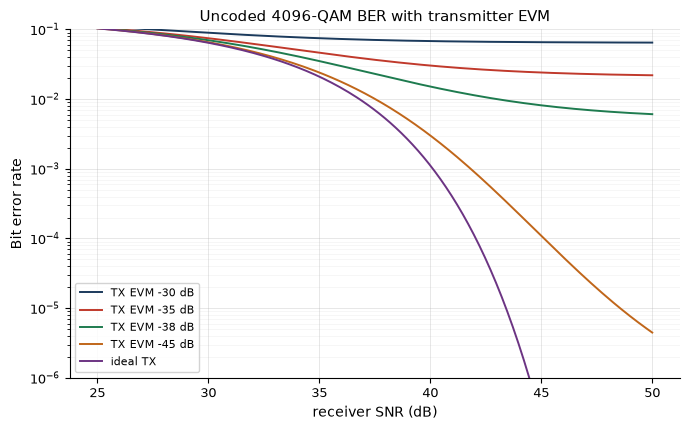

In [25]:
snr_rx = np.linspace(25, 50, 200)
th = {f"TX EVM {e} dB": cl.ber_mqam_gray(-lk.db(lk.undb(e) + lk.undb(-snr_rx)), 4096) for e in [-30, -35, -38, -45]}
th["ideal TX"] = cl.ber_mqam_gray(snr_rx, 4096)
f, ax = lk.fig("ber")
lk.ber_plot(ax, snr_rx, theory=th, xlabel="receiver SNR (dB)", ylim=(1e-6, 0.1))
ax.set_title("Uncoded 4096-QAM BER with transmitter EVM")
lk.show(f)

### Try it yourself 8.1
A transmitter has −38 dB EVM and the receiver SNR is 40 dB. What is the effective SNR (dB)?

In [27]:
answer_8_1 = None
lk.check("8.1 effective SNR with -38 dB EVM and 40 dB SNR", answer_8_1, -lk.db(lk.undb(-38) + lk.undb(-40)), atol=0.05)

[TODO] 8.1 effective SNR with -38 dB EVM and 40 dB SNR: not attempted yet: replace the None with your answer

## Key takeaways
* Frequency reuse trades SIR ($\propto (3N)^{n/2}$) for channels per cell; modern systems run $N = 1$.
* Erlang B: large trunks are more efficient, a law that shaped cell and switch dimensioning.
* OFDMA schedulers exploit multi-user diversity; proportional fairness balances throughput and fairness.
* DFT-s-OFDM lowers uplink PAPR; link adaptation plus HARQ tracks the channel within a few dB of Shannon.
* CSMA/CA is simple and fair but loses efficiency to collisions as the number of stations grows.
* High-order QAM is limited by transmitter EVM as much as by the receiver.

## Going further (hardware: USRP B200 / GNU Radio)
* Capture an LTE/NR downlink with gr01 (e.g. a local band 3/n78 carrier, where legal to receive)
  and find the synchronization signals by correlating with a Zadoff–Chu/m-sequence (Lab 4).
* Capture 2.4 GHz Wi-Fi traffic with gr01 at 20 MS/s and histogram the gaps between packets: you are
  looking at the backoff slots of Section 7.

## Exercises
1. **(Warm-up)** For μ = 1 and 273 RBs, compute the occupied bandwidth and the guard-band fraction
   of a 100 MHz NR carrier.
2. **(Core)** Sweep PF's α from 0 to 3 and plot total throughput against Jain's index. Explain the curve.
3. **(Core)** Add log-normal shadowing (σ = 8 dB) to Section 1 and recompute the 5th-percentile SIR
   for N = 1, 3 and 7. How much reuse does shadowing cost?
4. **(Stretch)** Implement Bianchi's fixed-point model of the DCF and compare with Section 7.

In [29]:
lk.summary()

[good] Lab 11 finished in 6.0 s. Self-checks: 0 passed, 0 failed, 3 still to do.